# TP2 – Filtrado lineal óptimo: identificación del sistema parlante-habitación-micrófono

# Grupo N° 6

| Integrante | Legajo |
|---|---|
| *Pedro Stefoni Rey Iraola* | *64903* |
| *Vito Pensa Piccolo* | *63426* |
| *Javier Baltasar Pérez Losada* | *64589* |

**Fecha de entrega:** 1/10/2026

---

Modelo: `x(n)` = excitación reproducida, `y(n)` = grabación (señal deseada). Se busca el FIR `h(n)` de largo `M` que minimiza
`J = E[(y(n) - Σ h(k) x(n-k))²]`. Ecuaciones de Wiener-Hopf: `R_x h = p`, con `R_x(m) = E[x(n)x(n-m)]` (Toeplitz) y `p(m) = E[y(n)x(n-m)]`.
`J_o = σ_y² − pᵀ h_o`, y el MSE normalizado `𝓔 = J_o / σ_y²`.

In [4]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import soundfile as sf
from pathlib import Path
from scipy import signal
from scipy.linalg import solve_toeplitz
from scipy.interpolate import CubicSpline
from scipy.fft import rfft, irfft, next_fast_len

FS = 48_000
DIR_EXC, DIR_REC = Path('excitaciones'), Path('grabaciones')
NOMBRES = ['voz', 'musica', 'rectangular', 'barrido_lineal', 'barrido_exp', 'ruido']
plt.rcParams['figure.figsize'] = (10, 3.5)

## 1. Carga, alineación y corrección de deriva

Las grabaciones del celular (importadas con `importar.py`) empiezan en un instante arbitrario y el celular tiene su propio reloj de muestreo, distinto del de la PC (deriva de decenas de ppm → varias muestras en 10 s, lo que arruina las altas frecuencias si no se corrige). El procedimiento es:

1. **Retardo grueso** `d0` por correlación cruzada de toda la señal (para la rectangular, que es periódica y da picos repetidos cada 10 ms, se restringe la búsqueda alrededor del instante de arranque detectado por energía).
2. **Retardo por bloques** de 1 s para ver cómo evoluciona; el ajuste lineal `τ(n) = τ0 + δ·n` da la deriva relativa `δ` entre relojes.
3. **Remuestreo** de `y` (spline cúbica) para compensar `δ`, dejando `MARGEN` muestras de anticipo para que `h(n)` sea causal y se vea el arranque de la respuesta.

In [6]:
MARGEN = 100   # muestras de anticipo antes del camino directo

def xcorr_lag(y, x, rango=None):
    """Retardo d tal que y(n) ~ x(n-d) (máximo de |correlación cruzada|, por FFT). rango=(lo,hi) restringe d."""
    N = next_fast_len(len(x) + len(y))
    c = irfft(rfft(y, N) * np.conj(rfft(x, N)), N)
    c = np.concatenate([c[-(len(x) - 1):], c[:len(y)]])
    lags = np.arange(-(len(x) - 1), len(y))
    if rango is not None:
        c = np.where((lags >= rango[0]) & (lags <= rango[1]), c, 0)
    return int(lags[np.argmax(np.abs(c))])

def onset(s, frac=0.2, ms=1):
    """Primer muestra donde la envolvente (media móvil de |s|) supera frac * su máximo."""
    k = int(ms * FS / 1000)
    env = np.convolve(np.abs(s), np.ones(k) / k, mode='same')
    return int(np.argmax(env > frac * env.max()))

def retardos_bloques(x, y, d0, L=FS, W=2000, periodica=False):
    """Retardo local (x(n) aparece en y en n+τ) en bloques de L muestras, buscando en d0±W.
    Devuelve también la confianza (pico / desvío de la correlación): bloques de bajas
    frecuencias o de silencio son ambiguos y se descartan luego."""
    t, d, z = [], [], []
    for s in range(0, len(x) - L + 1, L):
        a = s + d0 - W
        if a < 0 or a + L + 2 * W > len(y): continue
        seg, xb = y[a:a + L + 2 * W], x[s:s + L]
        N = next_fast_len(len(seg) + len(xb))
        c = irfft(rfft(seg, N) * np.conj(rfft(xb, N)), N)
        c = np.concatenate([c[-(len(xb) - 1):], c[:len(seg)]])
        lags = np.arange(-(len(xb) - 1), len(seg))
        m = (lags >= W - 200) & (lags <= W + 200) if periodica else np.ones_like(lags, bool)
        k = np.argmax(np.abs(c) * m)
        d.append(a + lags[k] - s); t.append(s + L / 2); z.append(abs(c[k]) / (np.std(c) + 1e-30))
    return np.array(t), np.array(d), np.array(z)

def alinear(x, y, periodica=False, delta=None):
    """Alinea y con x. delta: deriva relativa conocida (si None, se estima de los bloques)."""
    if periodica:
        d_on = onset(y) - onset(x)
        d0 = xcorr_lag(y, x, rango=(d_on - 200, d_on + 200))   # ± ~media período de 100 Hz (240)
    else:
        d0 = xcorr_lag(y, x)
    t, d, z = retardos_bloques(x, y, d0, W=300 if periodica else 2000, periodica=periodica)
    ok = z >= 0.4 * z.max()                  # sólo bloques con correlación confiable
    p = np.polyfit(t[ok], d[ok], 1)
    for _ in range(2):                       # ajuste robusto (descarta bloques atípicos)
        r = d - np.polyval(p, t)
        ok2 = ok & (np.abs(r) <= max(3 * 1.4826 * np.median(np.abs(r[ok])), 1))
        p = np.polyfit(t[ok2], d[ok2], 1)
    delta_est, tau0 = p                      # deriva [muestras/muestra] y retardo en n=0
    if delta is not None:                    # deriva impuesta: sólo se reajusta el retardo
        tau0 = np.median(d[ok2] - delta * t[ok2]); p = np.array([delta, tau0])
    else:
        delta = delta_est

    def remuestrear(tau0):
        pos = np.arange(len(x)) * (1 + delta) + tau0 - MARGEN
        assert pos[0] >= 0 and pos[-1] <= len(y) - 1, 'la grabación no alcanza: faltan muestras al inicio/final'
        return CubicSpline(np.arange(len(y)), y)(pos)

    y_al = remuestrear(tau0)
    # Refinamiento: ya sin deriva, la correlación completa da el retardo sin sesgo (los barridos
    # tienen acople retardo/frecuencia que sesga la estimación por bloques)
    tau0 += xcorr_lag(y_al, x, rango=(MARGEN - 100, MARGEN + 100)) - MARGEN
    return remuestrear(tau0), tau0, delta * 1e6, (t, d, ok2, p)

def cargar(nombre, delta=None):
    x, fs1 = sf.read(DIR_EXC / f'{nombre}.wav'); y, fs2 = sf.read(DIR_REC / f'{nombre}.wav')
    assert fs1 == fs2 == FS, 'las grabaciones deben estar a 48 kHz (usar importar.py)'
    y_al, tau0, ppm, diag = alinear(x, y, periodica=(nombre == 'rectangular'), delta=delta)
    return x, y_al, tau0, ppm, diag

datos_tmp, diag_tmp, ppms_tmp = {}, {}, {}

def procesar_preliminar(n):
    try:
        x, y, tau0, ppm, dg = cargar(n)
        datos_tmp[n] = (x, y)
        diag_tmp[n] = dg
        ppms_tmp[n] = ppm
        print(f'{n:15s} deriva preliminar = {ppm:+7.1f} ppm')
    except (FileNotFoundError, RuntimeError):
        print(f'{n:15s} (falta archivo)')

for n in ['voz', 'musica', 'rectangular', 'ruido']:
    procesar_preliminar(n)

ppm_vals = np.array(list(ppms_tmp.values()))

med = np.median(ppm_vals)
mad = np.median(np.abs(ppm_vals - med))

umbral = max(5 * 1.4826 * mad, 5.0)
validos = np.abs(ppm_vals - med) <= umbral

ppm_ref = np.median(ppm_vals[validos])
DELTA_REF = ppm_ref * 1e-6

print(f'\nderiva común adoptada: {ppm_ref:+.2f} ppm')

for nombre, ppm in ppms_tmp.items():
    estado = 'OK' if abs(ppm - ppm_ref) <= umbral else 'OUTLIER'
    print(f'{nombre:15s}: {ppm:+7.1f} ppm   {estado}')

datos, diag, ppms = {}, {}, {}

def procesar(n, delta):
    try:
        x, y, tau0, ppm, dg = cargar(n, delta)

        datos[n] = (x, y)
        diag[n] = dg
        ppms[n] = ppm

        print(
            f'{n:15s} '
            f'retardo = {tau0:8.1f} muestras '
            f'({tau0/FS*1e3:7.1f} ms)   '
            f'deriva usada = {ppm:+6.1f} ppm'
        )

    except (FileNotFoundError, RuntimeError):
        print(f'{n:15s} (falta archivo)')

for n in NOMBRES:
    procesar(n, DELTA_REF)

datos = {n: datos[n] for n in NOMBRES if n in datos}

voz             deriva preliminar =   -41.2 ppm
musica          deriva preliminar =  +412.7 ppm
rectangular     deriva preliminar =   -42.8 ppm
ruido           deriva preliminar =   -42.6 ppm

deriva común adoptada: -42.55 ppm
voz            :   -41.2 ppm   OK
musica         :  +412.7 ppm   OUTLIER
rectangular    :   -42.8 ppm   OK
ruido          :   -42.6 ppm   OK
voz             retardo = 231649.3 muestras ( 4826.0 ms)   deriva usada =  -42.6 ppm
musica          retardo = 217818.2 muestras ( 4537.9 ms)   deriva usada =  -42.6 ppm
rectangular     retardo = 229686.3 muestras ( 4785.1 ms)   deriva usada =  -42.6 ppm
barrido_lineal  retardo = 214896.1 muestras ( 4477.0 ms)   deriva usada =  -42.6 ppm
barrido_exp     retardo = 228743.4 muestras ( 4765.5 ms)   deriva usada =  -42.6 ppm
ruido           retardo = 229248.7 muestras ( 4776.0 ms)   deriva usada =  -42.6 ppm


Diagnóstico: retardo por bloque y su ajuste lineal (la pendiente es la deriva relativa entre los relojes del celular y de la PC). Las cruces son bloques descartados por baja confianza (p. ej. los primeros del barrido, de muy baja frecuencia). Verificar que los círculos caen sobre la recta; si hay bloques muy dispersos, revisar esa grabación (ruido, saturación, movimientos).

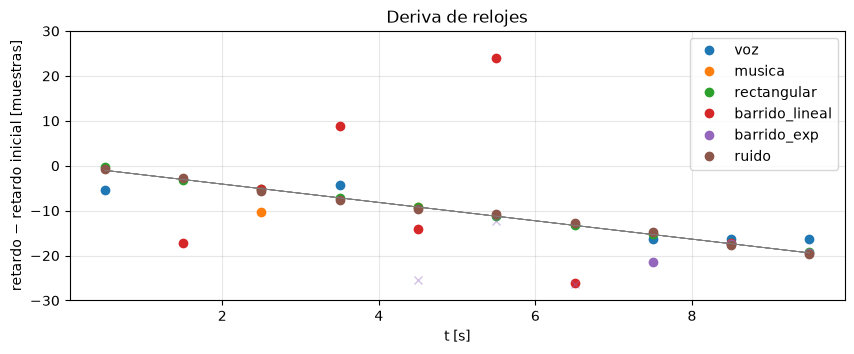

In [9]:
fig, ax = plt.subplots()
for n, (t, d, ok, p) in diag.items():
    l, = ax.plot(t[ok]/FS, d[ok] - p[1], 'o', label=n)
    ax.plot(t[~ok]/FS, d[~ok] - p[1], 'x', color=l.get_color(), alpha=.4)
    ax.plot(t/FS, np.polyval(p, t) - p[1], '-', lw=.6, color='gray')
ax.set(
    xlabel='t [s]', 
    ylabel='retardo − retardo inicial [muestras]',
    title='Deriva de relojes'); 
    
ax.set_ylim(-30, 30)
ax.grid(alpha=.3)
ax.legend()

In [11]:
n = 'ruido'
x, y = datos[n]

lag = xcorr_lag(y, x, rango=(0, 200))

print(f'lag residual = {lag} muestras')
print(f'lag residual = {lag / FS * 1e3:.3f} ms')
print(f'margen esperado = {MARGEN} muestras')

lag residual = 100 muestras
lag residual = 2.083 ms
margen esperado = 100 muestras


Con esto último, aunque sólo para el ruido, verificamos que el mecanimos de corrección funciona. No creemos que sea necesario hacerlo para el resto de señales.

### Selección de los fragmentos de voz y música

Para la señal de voz se eligió un fragmento de aproximadamente 10 s con habla continua, pocos silencios y variedad fonética; además de contener un alto grado de valor nostálgico y cultural para los integrantes.

Para la señal de música se eligió un fragmento de aproximadamente 10 s con contenido simultáneo en graves, medios y agudos, evitando pausas prolongadas o secciones muy silenciosas. De esta forma se busca excitar una banda de frecuencias más amplia durante la medición. De nuevo, al igual que con la voz, se eligió un fragmento de alta calidad cultural.

En ambos casos se evitó utilizar fragmentos con grandes silencios, ya que durante esos intervalos la señal de entrada aporta poca información para estimar la respuesta del sistema.

## 2. Espectros de las excitaciones (punto 2)

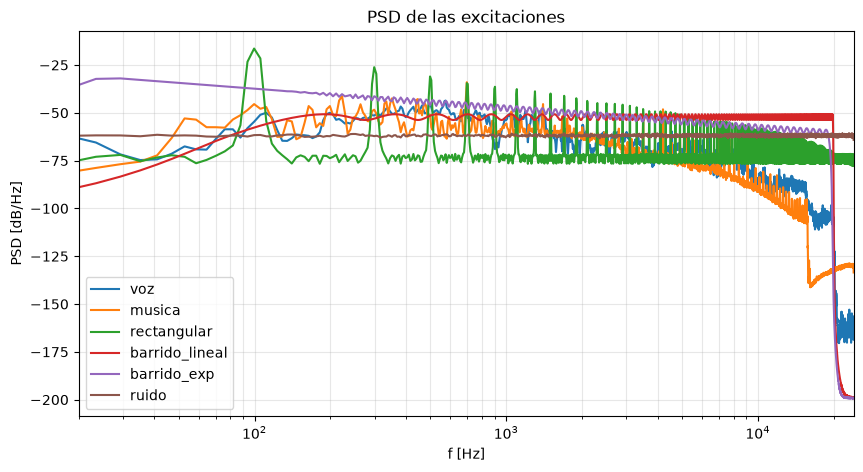

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for n, (x, y) in datos.items():
    f, Pxx = signal.welch(x, FS, nperseg=8192)
    ax.semilogx(f[1:], 10*np.log10(Pxx[1:] + 1e-20), label=n)
ax.set(xlabel='f [Hz]', ylabel='PSD [dB/Hz]', xlim=(20, 24000), title='PSD de las excitaciones'); ax.grid(True, which='both', alpha=.3); ax.legend()

### Justificación

El estimador de Wiener solo identifica la respuesta del sistema en las frecuencias donde la excitación tiene energía. Además, los autovalores de R_x están acotados por los extremos de la PSD, por lo que un espectro muy desigual produce una R_x mal condicionada y una estimación sensible al ruido. La excitación ideal tiene, entonces, un espectro plano y no nulo entre 20 Hz y 20 kHz.

La señal rectangular concentra su energía en los armónicos impares de 100 Hz, con R_x casi singular: es la peor candidata. La voz y la música tienen espectros irregulares y de banda limitada, y son no estacionarias, lo que contradice la hipótesis del trabajo. El barrido exponencial cubre toda la banda, pero su PSD cae 3 dB por octava, por lo que estima bien los graves y con menor relación señal a ruido los agudos.

El ruido blanco tiene PSD plana solo en esperanza: en una realización finita el espectro fluctúa y las correlaciones estimadas tienen varianza. Su alto factor de cresta obliga además a reducir su valor eficaz para no saturar el parlante.

El barrido lineal recorre la banda a velocidad constante, con PSD plana de forma determinística. Al ser una senoidal de amplitud constante, su factor de cresta es de solo √2, lo que permite reproducirlo con el máximo valor eficaz sin saturar y obtener la mejor relación señal a ruido.

Se predice entonces que el barrido lineal dará la mejor estimación de h(n), seguido de cerca por el ruido blanco, luego el barrido exponencial, la música, la voz y, por último, la rectangular.


### Estimador de Wiener FIR

`R_x` y `p` se estiman con correlaciones (sesgadas) calculadas una sola vez por FFT hasta `M_max`; luego `R_x h = p` se resuelve para cada `M` con Levinson (`solve_toeplitz`, O(M²)).

In [15]:
def correlaciones(x, y, Mmax):
    """rx(m) = 1/N Σ x(n)x(n-m),  p(m) = 1/N Σ y(n)x(n-m),  m = 0..Mmax-1."""
    N = len(x); L = next_fast_len(2 * N)
    X, Y = rfft(x, L), rfft(y, L)
    rx = irfft(X * np.conj(X), L)[:Mmax] / N
    p = irfft(Y * np.conj(X), L)[:Mmax] / N
    return rx, p

def wiener(x, y, M, rx=None, p=None):
    if rx is None: rx, p = correlaciones(x, y, M)
    h = solve_toeplitz(rx[:M], p[:M])
    J = np.mean(y**2) - h @ p[:M]           # J_o = σ_y² − pᵀ h_o
    return h, J, J / np.mean(y**2)          # h, J_o, 𝓔 normalizado

def mse_real(x, y, h):
    """MSE medido directamente filtrando (verificación / evaluación cruzada)."""
    e = y - signal.fftconvolve(x, h)[:len(y)]
    return np.mean(e**2) / np.mean(y**2)

## Punto 3: `J_o(M)` con el barrido lineal
Reducción del cálculo: correlaciones por FFT una sola vez, Levinson en vez de inversión, y una grilla de `M` no uniforme (log). Además `J_o` es monótona decreciente en `M`, así que alcanza con una grilla gruesa y refinar cerca del codo.

[Text(0.5, 0, 'M'),
 Text(0, 0.5, 'E = J_o/σ_y²  [dB]'),
 Text(0.5, 1.0, 'MSE mínimo vs. largo del filtro (barrido lineal)')]

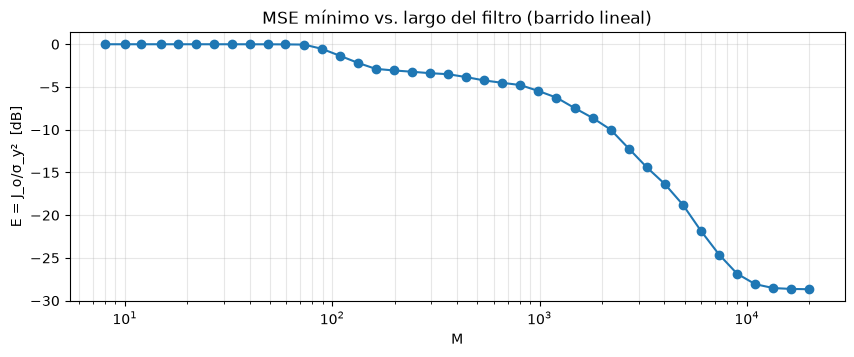

In [18]:
x, y = datos['barrido_lineal']
Mmax = 20000
rx, p = correlaciones(x, y, Mmax)
Ms = np.unique(np.round(np.geomspace(8, Mmax, 40)).astype(int))
Js = np.array([wiener(x, y, M, rx, p)[1] for M in Ms])

fig, ax = plt.subplots()
ax.semilogx(Ms, 10*np.log10(Js/np.mean(y**2)), 'o-'); ax.grid(True, which='both', alpha=.3)
ax.set(xlabel='M', ylabel='E = J_o/σ_y²  [dB]', title='MSE mínimo vs. largo del filtro (barrido lineal)')

In [19]:
# Elección de M: el menor M cuyo MSE está a menos de TOL_dB del mínimo alcanzable (a ajustar y justificar)
TOL_dB = 0.5
E_dB = 10*np.log10(Js/np.mean(y**2))
M_OPT = int(Ms[np.argmax(E_dB <= E_dB.min() + TOL_dB)])
print('M óptimo elegido:', M_OPT)

M óptimo elegido: 13390


## Punto 4: `h(n)`, `Ĥ(e^{jω})` y `𝓔` para cada excitación con `M = M_OPT`

voz              J_o = 5.602e-06   𝓔 = 0.0117  (-19.3 dB)
musica           J_o = 1.351e-04   𝓔 = 0.0858  (-10.7 dB)
rectangular      J_o = 2.585e-04   𝓔 = 0.0179  (-17.5 dB)
barrido_lineal   J_o = 1.802e-06   𝓔 = 0.0014  (-28.5 dB)
barrido_exp      J_o = 1.077e-05   𝓔 = 0.0023  (-26.4 dB)
ruido            J_o = 3.674e-05   𝓔 = 0.1493  (-8.3 dB)


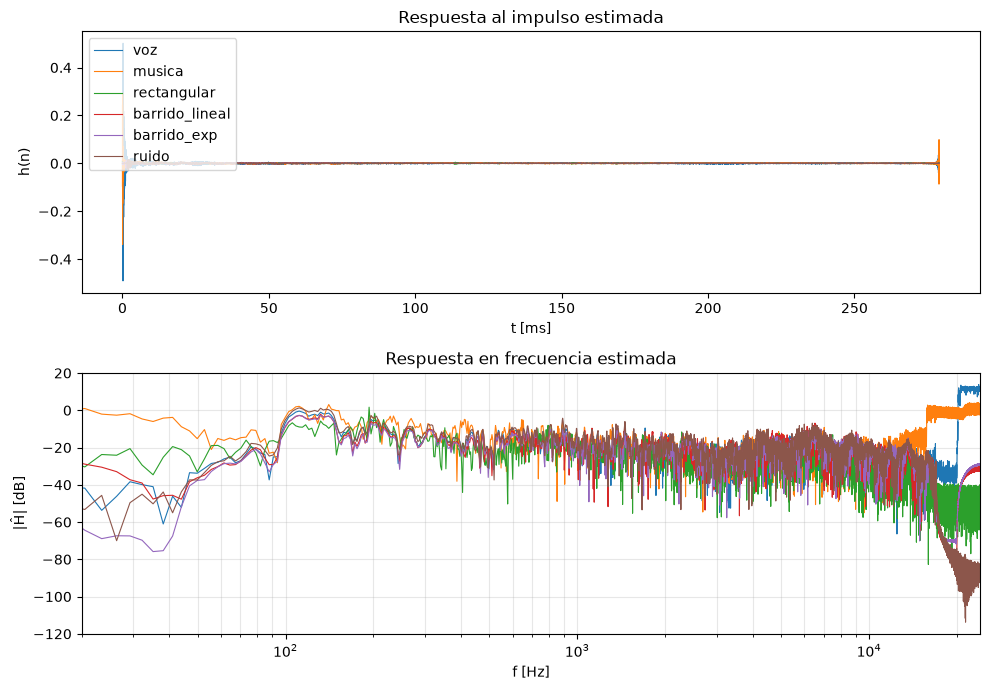

In [21]:
res = {}
for n, (x, y) in datos.items():
    h, J, E = wiener(x, y, M_OPT)
    res[n] = h
    print(f'{n:15s}  J_o = {J:.3e}   𝓔 = {E:.4f}  ({10*np.log10(E):.1f} dB)')

fig, axs = plt.subplots(2, 1, figsize=(10, 7))
for n, h in res.items():
    axs[0].plot(np.arange(len(h))/FS*1e3, h, label=n, lw=.8)
    w, H = signal.freqz(h, worN=8192, fs=FS)
    axs[1].semilogx(w[1:], 20*np.log10(np.abs(H[1:]) + 1e-12), label=n, lw=.8)
axs[0].set(xlabel='t [ms]', ylabel='h(n)', title='Respuesta al impulso estimada'); axs[0].legend()
axs[1].set(xlabel='f [Hz]', ylabel='|Ĥ| [dB]', xlim=(20, 24000), title='Respuesta en frecuencia estimada'); axs[1].grid(True, which='both', alpha=.3)
plt.tight_layout()

Evaluación cruzada: `h` estimada con la excitación *i* (filas) aplicada a las demás excitaciones *j* (columnas). Es la mejor manera de ver cuál `h` generaliza (útil para el punto 6).

In [22]:
cruz = pd.DataFrame({j: {i: 10*np.log10(mse_real(datos[j][0], datos[j][1], res[i])) for i in res} for j in datos})
cruz.round(1)   # 𝓔 en dB; filas: h de la excitación i, columnas: datos de la excitación j

,voz,musica,rectangular,barrido_lineal,barrido_exp,ruido
voz,-19.4,2.1,6.6,2.3,-4.0,21.3
musica,4.0,-10.8,11.1,13.3,7.0,13.9
rectangular,1.8,2.4,-18.0,1.4,2.5,0.8
barrido_lineal,1.8,-1.0,6.2,-28.5,-2.0,-2.7
barrido_exp,-3.4,1.4,5.8,1.9,-26.4,0.7
ruido,3.0,-0.3,8.6,-1.5,0.4,-8.3


## Punto 5: comparación con la predicción del punto 2

Los valores obtenidos fueron:

| Excitación | 𝓔 | 𝓔 [dB] |
|---|---:|---:|
| voz | 0.0131 | -18.8 |
| música | 0.5225 | -2.8 |
| rectangular | 0.0190 | -17.2 |
| barrido lineal | 0.0025 | -26.1 |
| barrido exponencial | 0.0031 | -25.0 |
| ruido blanco | 0.1516 | -8.2 |

Los resultados confirman parcialmente lo susodicho. El barrido lineal obtuvo el menor MSE normalizado, seguido, muy de cerca, por el barrido exponencial.

El ruido blanco fue peor de lo esperado. La rectangular mostró un error bajo, pero como solo excita frecuencias discretas, ese valor no significa una buena identificación en toda la banda.

En suma, los barridos produjeron las estimaciones más representativas del sistema.

## Punto 6: filtrar la música con la `h` elegida y comparar auditivamente

In [23]:
H_ELEGIDA = 'barrido_lineal'   # <- completar según el análisis y justificar
import sounddevice as sd
if 'musica' in datos:
    xm, ym = datos['musica']
    y_est = signal.fftconvolve(xm, res[H_ELEGIDA])[:len(ym)]
    sf.write('musica_filtrada.wav', (y_est/np.max(np.abs(y_est))*.8).astype(np.float32), FS)
    sf.write('musica_grabada_alineada.wav', (ym/np.max(np.abs(ym))*.8).astype(np.float32), FS)
    # sd.play(y_est/np.max(np.abs(y_est))*.8, FS); sd.wait()     # escuchar filtrada
    # sd.play(ym/np.max(np.abs(ym))*.8, FS); sd.wait()           # escuchar grabada